1. Loading the dataset...
Data loaded successfully: 244 dining records found.

2. Generating Statistical Summaries...
       total_bill         tip        size  tip_percentage
count  244.000000  244.000000  244.000000      244.000000
mean    19.785943    2.998279    2.569672       16.080258
std      8.902412    1.383638    0.951100        6.107220
min      3.070000    1.000000    1.000000        3.563814
25%     13.347500    2.000000    2.000000       12.912736
50%     17.795000    2.900000    2.000000       15.476977
75%     24.127500    3.562500    3.000000       19.147549
max     50.810000   10.000000    6.000000       71.034483
-> Statistical summary saved locally as 'statistical_summary.txt'

3. Building the Visual Insights Dashboard...


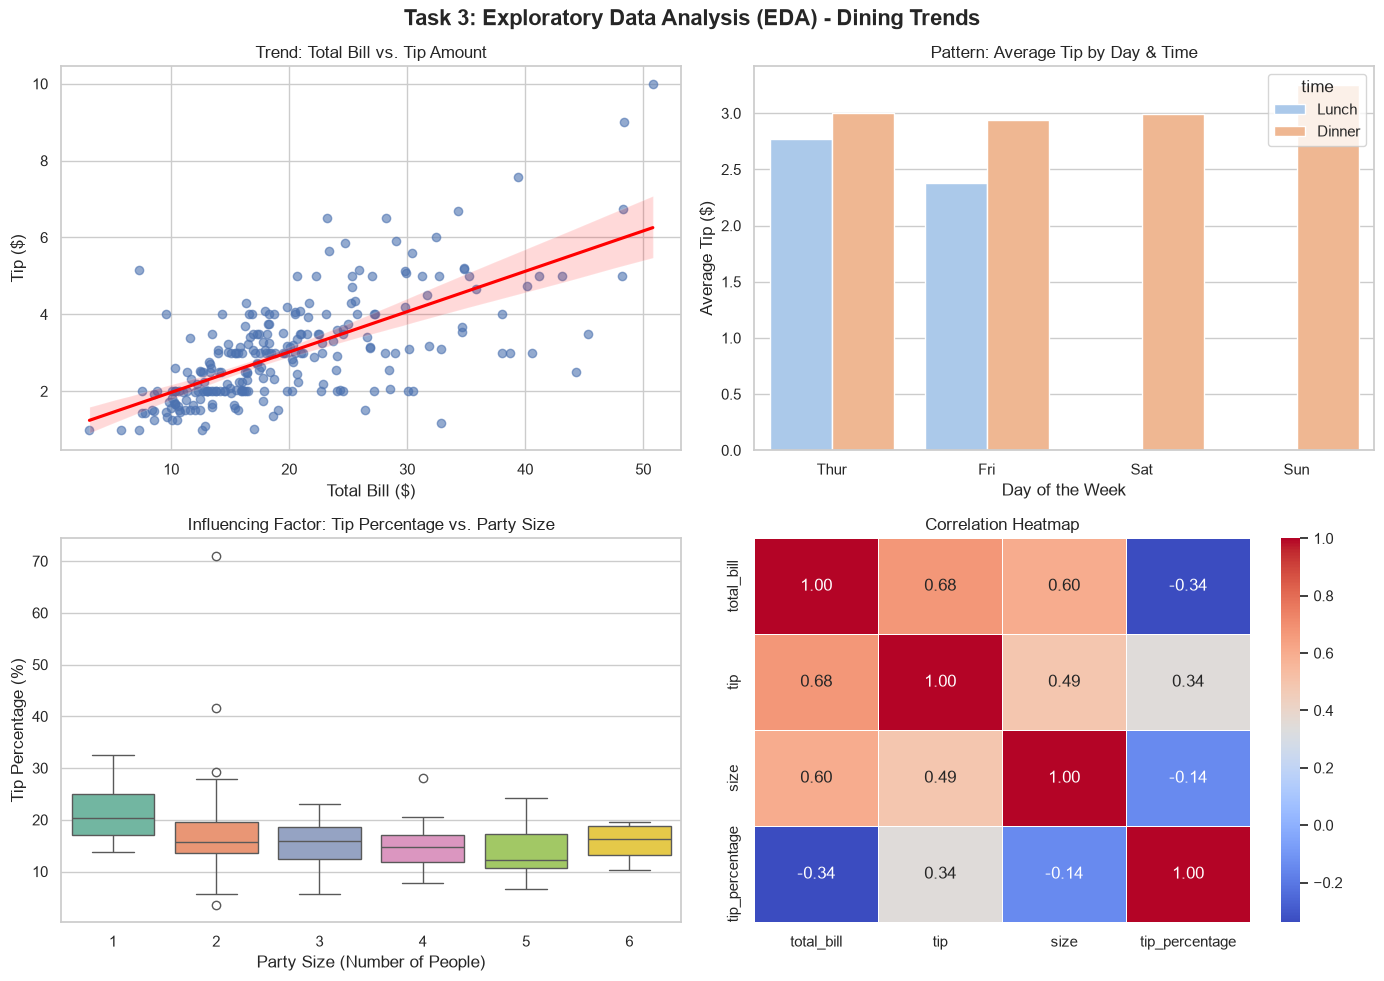


Task complete! Visual dashboard saved as 'eda_insights_dashboard.png'.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean output
warnings.filterwarnings('ignore')

print("1. Loading the dataset...")
# Seaborn has this dataset built-in, so no need to download CSVs
df = sns.load_dataset('tips')
print(f"Data loaded successfully: {df.shape[0]} dining records found.")

# Feature Engineering: Creating a new column to show analytical thinking
# Looking at the raw tip is okay, but Tip Percentage tells a better story
df['tip_percentage'] = (df['tip'] / df['total_bill']) * 100

print("\n2. Generating Statistical Summaries...")
# Let's get the basic math (mean, min, max, quartiles)
stats_summary = df.describe()
print(stats_summary)

# Saving the stats to a text file for our final report
with open("statistical_summary.txt", "w") as file:
    file.write("--- Restaurant Tips: Statistical Summary ---\n\n")
    file.write(stats_summary.to_string())
print("-> Statistical summary saved locally as 'statistical_summary.txt'")

print("\n3. Building the Visual Insights Dashboard...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Task 3: Exploratory Data Analysis (EDA) - Dining Trends", fontsize=16, fontweight="bold")

# Chart A: Total Bill vs Tip (Finding the trend line)
sns.regplot(ax=axes[0, 0], data=df, x="total_bill", y="tip", 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0, 0].set_title("Trend: Total Bill vs. Tip Amount")
axes[0, 0].set_xlabel("Total Bill ($)")
axes[0, 0].set_ylabel("Tip ($)")

# Chart B: Average Tip by Day and Time
sns.barplot(ax=axes[0, 1], data=df, x="day", y="tip", hue="time", palette="pastel", errorbar=None)
axes[0, 1].set_title("Pattern: Average Tip by Day & Time")
axes[0, 1].set_xlabel("Day of the Week")
axes[0, 1].set_ylabel("Average Tip ($)")

# Chart C: Do bigger groups tip better? (Tip Percentage by Party Size)
sns.boxplot(ax=axes[1, 0], data=df, x="size", y="tip_percentage", palette="Set2")
axes[1, 0].set_title("Influencing Factor: Tip Percentage vs. Party Size")
axes[1, 0].set_xlabel("Party Size (Number of People)")
axes[1, 0].set_ylabel("Tip Percentage (%)")

# Chart D: Correlation Heatmap (How everything connects mathematically)
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(ax=axes[1, 1], data=numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_insights_dashboard.png", dpi=300)
plt.show()

print("\nTask complete! Visual dashboard saved as 'eda_insights_dashboard.png'.")